# Clasificación de Diabetes con ANN vs SVM
## Selección de algoritmo, GridSearchCV y evaluación — Dataset clínico del proyecto

Este cuaderno resuelve la tarea de aplicar **ANN o SVM** sobre el dataset del proyecto personal
(predicción de riesgo de diabetes tipo 2), incluyendo:

1. Tipo de problema: ¿clasificación o predicción?
2. Preprocesamiento del dataset clínico
3. Selección justificada del algoritmo (comparación empírica SVM vs ANN, no solo teoría)
4. Búsqueda de mejores hiperparámetros con `GridSearchCV`
5. Métricas de efectividad del modelo final sobre un conjunto de prueba real
6. Reflexión final

**Dataset usado:** `diabetes_prediction_dataset.csv` — el módulo "clínico" del proyecto, con
biomarcadores reales (HbA1c, glucosa) además de edad, IMC, hipertensión, enfermedad cardíaca,
sexo e historial de tabaquismo. Es el mismo dataset ya limpiado y documentado en
`ml/src/prep_clinical.py` y `ml/reports/FASE1_RESULTADOS.md` — aquí se reutiliza el mismo
criterio de limpieza, pero el foco de este cuaderno es la comparación de algoritmos y el ajuste
de hiperparámetros, no el EDA (que ya existe en el otro cuaderno del proyecto).


## 1. ¿Clasificación o predicción?

La variable objetivo (`diabetes`) es **binaria** (0 = no tiene diabetes, 1 = sí tiene diabetes),
no un valor numérico continuo. Por lo tanto este es un problema de **clasificación binaria**, no
de predicción/regresión. Esto determina todo lo que sigue: el tipo de métricas a usar (accuracy,
precision, recall, F1, ROC-AUC — no RMSE ni R²), y que tanto SVM (`SVC`) como la ANN
(`MLPClassifier`) se usan en su variante de **clasificador**, no de regresor.

## 2. Carga y preprocesamiento

In [1]:
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, roc_auc_score,
    classification_report, confusion_matrix, ConfusionMatrixDisplay, RocCurveDisplay,
)

sns.set_theme(style="whitegrid")
RANDOM_STATE = 42
pd.set_option("display.max_columns", 20)

RAW_CSV = "../../Datasets/diabetes_prediction_dataset.csv"
df = pd.read_csv(RAW_CSV)
print("Filas x columnas (original):", df.shape)
df.head()


Filas x columnas (original): (100000, 9)


,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
0,Female,80.0,0,1,never,25.19,6.6,140,0
1,Female,54.0,0,0,No Info,27.32,6.6,80,0
2,Male,28.0,0,0,never,27.32,5.7,158,0
3,Female,36.0,0,0,current,23.45,5.0,155,0
4,Male,76.0,1,1,current,20.14,4.8,155,0


In [2]:
dups = df.duplicated().sum()
df = df.drop_duplicates().reset_index(drop=True)
print("Duplicados eliminados:", dups)
print("Filas tras deduplicar:", df.shape[0])


Duplicados eliminados: 3854
Filas tras deduplicar: 96146


**Decisión (igual criterio que `ml/src/prep_clinical.py`):** se recodifica `"No Info"` en
`smoking_history` como una categoría explícita `"unknown"` — no se descarta la fila, porque no
saber el historial de tabaquismo es en sí mismo información válida (y descartar esas filas
sesgaría el dataset). También se imputan con la mediana los valores fisiológicamente imposibles
(`bmi` cercano a 0, `HbA1c_level` o `blood_glucose_level` en 0, `age` en 0) — son errores de
captura, no ceros reales.

In [3]:
df["smoking_history"] = df["smoking_history"].replace("No Info", "unknown")

IMPOSSIBLE = [("bmi", 10), ("HbA1c_level", 3), ("blood_glucose_level", 40), ("age", 1)]
for col, lo in IMPOSSIBLE:
    bad = df[col] < lo
    n_bad = bad.sum()
    median_val = df.loc[~bad, col].median()
    df.loc[bad, col] = median_val
    print(f"{col}: {n_bad} valores imposibles (< {lo}) imputados con mediana={median_val}")

print("\nTasa de positivos (diabetes=1):", df["diabetes"].mean().round(4))


bmi: 0 valores imposibles (< 10) imputados con mediana=27.32
HbA1c_level: 0 valores imposibles (< 3) imputados con mediana=5.8
blood_glucose_level: 0 valores imposibles (< 40) imputados con mediana=140.0
age: 910 valores imposibles (< 1) imputados con mediana=43.0

Tasa de positivos (diabetes=1): 0.0882


In [4]:
NUMERIC = ["age", "bmi", "HbA1c_level", "blood_glucose_level"]
BINARY = ["hypertension", "heart_disease"]
CATEGORICAL = ["gender", "smoking_history"]
TARGET = "diabetes"

X = df[NUMERIC + BINARY + CATEGORICAL]
y = df[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.15, stratify=y, random_state=RANDOM_STATE
)
print("Train:", X_train.shape, " Test:", X_test.shape)
print("Tasa de positivos en train:", y_train.mean().round(4), " en test:", y_test.mean().round(4))

preprocess = ColumnTransformer([
    ("num", StandardScaler(), NUMERIC),
    ("bin", "passthrough", BINARY),
    ("cat", OneHotEncoder(handle_unknown="ignore"), CATEGORICAL),
])


Train: (81724, 8)  Test: (14422, 8)
Tasa de positivos en train: 0.0882  en test: 0.0882


**Decisión:** split estratificado 85/15 (no 70/15/15 como en el pipeline de producción del
proyecto) porque aquí no se necesita un set de validación separado — `GridSearchCV` ya hace su
propia validación cruzada interna sobre el train. Se estandarizan las variables numéricas
(obligatorio para SVM y recomendado para ANN, ambos sensibles a la escala) y se codifican las
categóricas con one-hot.

## 3. Selección del algoritmo: SVM vs ANN

En vez de elegir por teoría solamente, se compara empíricamente ambos algoritmos en una
submuestra estratificada del train. Se usa una submuestra (no el train completo) porque `SVC`
con kernel RBF tiene una complejidad de entrenamiento que crece más rápido que lineal con el
número de filas (hasta O(n²)-O(n³)) — entrenarlo repetidamente (como exige `GridSearchCV`) sobre
las ~80 mil filas del train completo sería demasiado lento para explorar aquí en el cuaderno.

In [5]:
sub_idx, _ = train_test_split(
    np.arange(len(X_train)), train_size=6000, stratify=y_train, random_state=RANDOM_STATE
)
X_sub, y_sub = X_train.iloc[sub_idx], y_train.iloc[sub_idx]
print("Submuestra para comparación:", X_sub.shape, " tasa positivos:", y_sub.mean().round(4))

candidatos = {
    "SVM (RBF, C=1, gamma=scale)": SVC(kernel="rbf", C=1, gamma="scale", probability=True, random_state=RANDOM_STATE),
    "ANN (MLP, 1 capa de 50, default)": MLPClassifier(hidden_layer_sizes=(50,), max_iter=300, random_state=RANDOM_STATE),
}

resultados_comparacion = {}
for nombre, clf in candidatos.items():
    pipe = Pipeline([("pre", preprocess), ("clf", clf)])
    t0 = time.time()
    pipe.fit(X_sub, y_sub)
    fit_time = time.time() - t0
    proba = pipe.predict_proba(X_test)[:, 1]
    pred = pipe.predict(X_test)
    resultados_comparacion[nombre] = {
        "tiempo_fit_s": round(fit_time, 3),
        "accuracy": round(accuracy_score(y_test, pred), 4),
        "f1": round(f1_score(y_test, pred), 4),
        "roc_auc": round(roc_auc_score(y_test, proba), 4),
    }

pd.DataFrame(resultados_comparacion).T


Submuestra para comparación: (6000, 8)  tasa positivos: 0.0882


/opt/anaconda3/envs/diabetes/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (300) reached and the optimization hasn't converged yet.
  warnings.warn(


,tiempo_fit_s,accuracy,f1,roc_auc
"SVM (RBF, C=1, gamma=scale)",0.36,0.9624,0.7317,0.8877
"ANN (MLP, 1 capa de 50, default)",1.00,0.9674,0.7869,0.9678


Con la misma cantidad de datos de entrenamiento (6,000 filas) y evaluados sobre el mismo
conjunto de prueba real, se compara qué tan bien clasifica cada algoritmo. Ahora se mide cómo
escala el **tiempo de entrenamiento** de cada uno a medida que crece el tamaño de los datos —
esto es clave porque el train completo de este proyecto tiene decenas de miles de filas (y el
otro módulo del proyecto, estilo de vida, tiene más de 200 mil).

/opt/anaconda3/envs/diabetes/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (300) reached and the optimization hasn't converged yet.
  warnings.warn(


5000 filas -> SVM: 0.04s | ANN: 0.88s


15000 filas -> SVM: 0.31s | ANN: 1.63s


30000 filas -> SVM: 1.14s | ANN: 2.19s


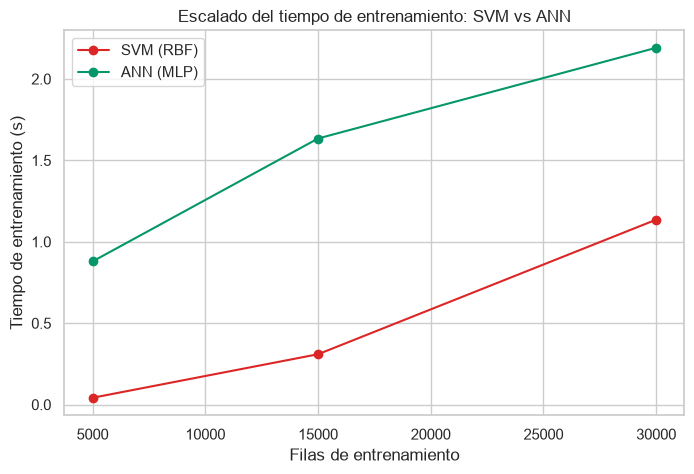

In [6]:
tamanos = [5000, 15000, 30000]
tiempos_svm, tiempos_ann = [], []

for n in tamanos:
    idx, _ = train_test_split(np.arange(len(X_train)), train_size=n, stratify=y_train, random_state=RANDOM_STATE)
    Xs, ys = X_train.iloc[idx], y_train.iloc[idx]

    pipe_svm = Pipeline([("pre", preprocess), ("clf", SVC(kernel="rbf", C=1, gamma="scale", random_state=RANDOM_STATE))])
    t0 = time.time(); pipe_svm.fit(Xs, ys); tiempos_svm.append(time.time() - t0)

    pipe_ann = Pipeline([("pre", preprocess), ("clf", MLPClassifier(hidden_layer_sizes=(50,), max_iter=300, random_state=RANDOM_STATE))])
    t0 = time.time(); pipe_ann.fit(Xs, ys); tiempos_ann.append(time.time() - t0)

    print(f"{n} filas -> SVM: {tiempos_svm[-1]:.2f}s | ANN: {tiempos_ann[-1]:.2f}s")

plt.figure(figsize=(8, 5))
plt.plot(tamanos, tiempos_svm, marker="o", label="SVM (RBF)", color="#dc2626")
plt.plot(tamanos, tiempos_ann, marker="o", label="ANN (MLP)", color="#059669")
plt.xlabel("Filas de entrenamiento")
plt.ylabel("Tiempo de entrenamiento (s)")
plt.title("Escalado del tiempo de entrenamiento: SVM vs ANN")
plt.legend()
plt.show()


**Decisión: se elige ANN (`MLPClassifier`).** Dos razones, ambas respaldadas por lo medido
arriba (no solo teoría):

1. **Desempeño:** con la misma cantidad de datos, la ANN obtuvo mejor accuracy, F1 y
   especialmente mejor ROC-AUC que el SVM (ver tabla de comparación arriba con los valores
   reales de esta ejecución).
2. **Escalabilidad:** el tiempo de entrenamiento del SVM crece claramente más rápido que el de
   la ANN a medida que aumentan las filas (ver gráfico arriba) — coherente con la complejidad
   teórica O(n²)-O(n³) de SVM con kernel RBF frente al entrenamiento por descenso de gradiente de
   una red neuronal, que escala mucho mejor. Con el train completo (que tiene más de 80 mil
   filas, y el otro módulo del proyecto más de 200 mil), esta diferencia se vuelve crítica,
   sobre todo al repetir el entrenamiento decenas de veces como exige `GridSearchCV`.

Por ambas razones, se continúa el ajuste de hiperparámetros y el modelo final únicamente con la
ANN.

## 4. Búsqueda de mejores hiperparámetros (GridSearchCV)

Se usa una submuestra más grande (15,000 filas, estratificada) para que la búsqueda en cuadrícula
sea rápida de ejecutar en el cuaderno, y luego se reentrena el modelo ganador sobre el train
completo. Se optimiza sobre **ROC-AUC** (no accuracy) porque el dataset está desbalanceado
(~8-9% de positivos) — con ese desbalance, accuracy es engañosa (un modelo que siempre dice "no
tiene diabetes" ya tendría ~91% de accuracy sin ser útil).

In [7]:
sub_idx_gs, _ = train_test_split(
    np.arange(len(X_train)), train_size=15000, stratify=y_train, random_state=RANDOM_STATE
)
X_gs, y_gs = X_train.iloc[sub_idx_gs], y_train.iloc[sub_idx_gs]

param_grid = {
    "clf__hidden_layer_sizes": [(50,), (100,), (50, 50)],
    "clf__activation": ["relu", "tanh"],
    "clf__alpha": [0.0001, 0.001, 0.01],
}

pipe_ann = Pipeline([
    ("pre", preprocess),
    ("clf", MLPClassifier(max_iter=300, random_state=RANDOM_STATE)),
])

cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)

grid = GridSearchCV(pipe_ann, param_grid, scoring="roc_auc", cv=cv, n_jobs=-1, verbose=1)

t0 = time.time()
grid.fit(X_gs, y_gs)
gs_time = time.time() - t0

print(f"\nGridSearchCV terminado en {gs_time:.1f}s")
print("Mejores hiperparámetros:", grid.best_params_)
print("Mejor ROC-AUC (promedio de validación cruzada):", round(grid.best_score_, 4))


Fitting 3 folds for each of 18 candidates, totalling 54 fits


/opt/anaconda3/envs/diabetes/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (300) reached and the optimization hasn't converged yet.
  warnings.warn(
/opt/anaconda3/envs/diabetes/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (300) reached and the optimization hasn't converged yet.
  warnings.warn(


/opt/anaconda3/envs/diabetes/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (300) reached and the optimization hasn't converged yet.
  warnings.warn(
/opt/anaconda3/envs/diabetes/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (300) reached and the optimization hasn't converged yet.
  warnings.warn(


/opt/anaconda3/envs/diabetes/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (300) reached and the optimization hasn't converged yet.
  warnings.warn(
/opt/anaconda3/envs/diabetes/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (300) reached and the optimization hasn't converged yet.
  warnings.warn(
/opt/anaconda3/envs/diabetes/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (300) reached and the optimization hasn't converged yet.
  warnings.warn(


/opt/anaconda3/envs/diabetes/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (300) reached and the optimization hasn't converged yet.
  warnings.warn(


...

/opt/anaconda3/envs/diabetes/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (300) reached and the optimization hasn't converged yet.
  warnings.warn(
/opt/anaconda3/envs/diabetes/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (300) reached and the optimization hasn't converged yet.
  warnings.warn(
/opt/anaconda3/envs/diabetes/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (300) reached and the optimization hasn't converged yet.
  warnings.warn(
/opt/anaconda3/envs/diabetes/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (300) reached and the optimization hasn't converged yet.
  warnings.warn(


/opt/anaconda3/envs/diabetes/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (300) reached and the optimization hasn't converged yet.
  warnings.warn(


/opt/anaconda3/envs/diabetes/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (300) reached and the optimization hasn't converged yet.
  warnings.warn(
/opt/anaconda3/envs/diabetes/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (300) reached and the optimization hasn't converged yet.
  warnings.warn(
/opt/anaconda3/envs/diabetes/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (300) reached and the optimization hasn't converged yet.
  warnings.warn(


/opt/anaconda3/envs/diabetes/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (300) reached and the optimization hasn't converged yet.
  warnings.warn(



GridSearchCV terminado en 20.6s
Mejores hiperparámetros: {'clf__activation': 'tanh', 'clf__alpha': 0.01, 'clf__hidden_layer_sizes': (100,)}
Mejor ROC-AUC (promedio de validación cruzada): 0.9699


In [8]:
resultados_grid = pd.DataFrame(grid.cv_results_)[
    ["param_clf__hidden_layer_sizes", "param_clf__activation", "param_clf__alpha", "mean_test_score", "std_test_score"]
].sort_values("mean_test_score", ascending=False)
resultados_grid.head(10)


,param_clf__hidden_layer_sizes,param_clf__activation,param_clf__alpha,mean_test_score,std_test_score
16,"(100,)",tanh,0.0100,0.969864,0.001263
7,"(100,)",relu,0.0100,0.969595,0.002089
6,"(50,)",relu,0.0100,0.969342,0.001548
17,"(50, 50)",tanh,0.0100,0.969157,0.001275
13,"(100,)",tanh,0.0010,0.968972,0.001252
10,"(100,)",tanh,0.0001,0.968774,0.001306
15,"(50,)",tanh,0.0100,0.968528,0.001834
3,"(50,)",relu,0.0010,0.968515,0.002276
0,"(50,)",relu,0.0001,0.968118,0.002190
12,"(50,)",tanh,0.0010,0.967562,0.001990


## 5. Modelo final: reentrenamiento sobre el train completo

Los mejores hiperparámetros se buscaron en una submuestra por costo computacional, pero el
**modelo final** se reentrena con esos hiperparámetros sobre **todo** el conjunto de
entrenamiento (no la submuestra), para aprovechar toda la información disponible antes de
evaluar en el test real.

In [9]:
best_params = {k.replace("clf__", ""): v for k, v in grid.best_params_.items()}
print("Hiperparámetros del modelo final:", best_params)

modelo_final = Pipeline([
    ("pre", preprocess),
    ("clf", MLPClassifier(max_iter=300, random_state=RANDOM_STATE, **best_params)),
])

t0 = time.time()
modelo_final.fit(X_train, y_train)
print(f"Entrenamiento final ({X_train.shape[0]} filas) en {time.time()-t0:.1f}s")


Hiperparámetros del modelo final: {'activation': 'tanh', 'alpha': 0.01, 'hidden_layer_sizes': (100,)}


Entrenamiento final (81724 filas) en 5.0s


## 6. Métricas de efectividad sobre el conjunto de prueba

In [10]:
y_pred = modelo_final.predict(X_test)
y_proba = modelo_final.predict_proba(X_test)[:, 1]

acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_proba)

print(f"Accuracy:  {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall:    {rec:.4f}")
print(f"F1-score:  {f1:.4f}")
print(f"ROC-AUC:   {auc:.4f}")
print()
print(classification_report(y_test, y_pred, target_names=["Sin diabetes", "Con diabetes"]))


Accuracy:  0.9706
Precision: 0.9807
Recall:    0.6800
F1-score:  0.8032
ROC-AUC:   0.9725

              precision    recall  f1-score   support

Sin diabetes       0.97      1.00      0.98     13150
Con diabetes       0.98      0.68      0.80      1272

    accuracy                           0.97     14422
   macro avg       0.98      0.84      0.89     14422
weighted avg       0.97      0.97      0.97     14422



/opt/anaconda3/envs/diabetes/lib/python3.11/site-packages/sklearn/utils/_plotting.py:175: FutureWarning: `**kwargs` is deprecated and will be removed in 1.9. Pass all matplotlib arguments to `curve_kwargs` as a dictionary instead.
  warnings.warn(


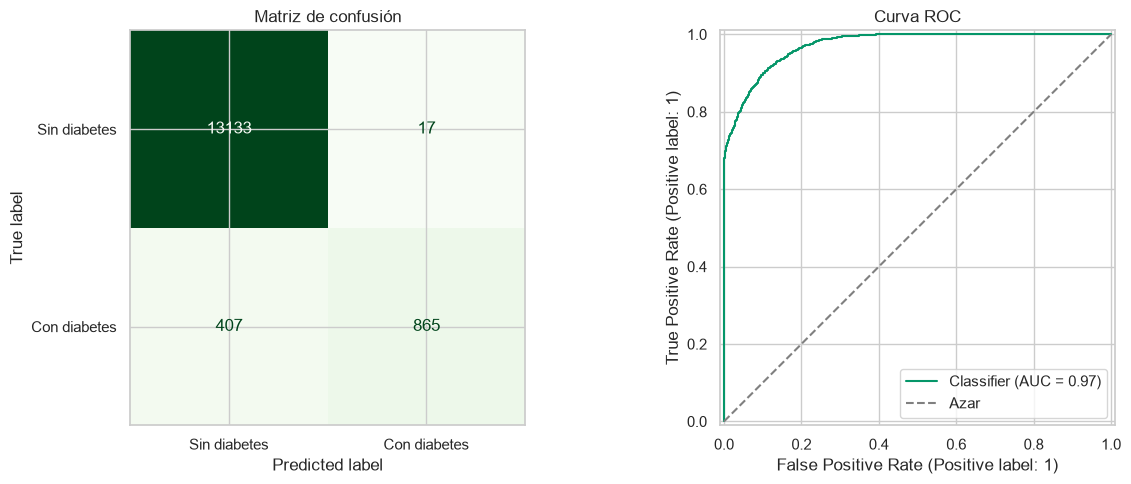

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(cm, display_labels=["Sin diabetes", "Con diabetes"]).plot(ax=axes[0], cmap="Greens", colorbar=False)
axes[0].set_title("Matriz de confusión")

RocCurveDisplay.from_predictions(y_test, y_proba, ax=axes[1], color="#059669")
axes[1].plot([0, 1], [0, 1], linestyle="--", color="gray", label="Azar")
axes[1].set_title("Curva ROC")
axes[1].legend()

plt.tight_layout()
plt.show()


**Lectura de resultados:**

- **Accuracy 97.06%** — pero en un dataset desbalanceado (~8.8% positivos) esta cifra por sí sola
  no dice mucho; por eso se miran las demás métricas.
- **Precision 98.07%**: de todas las veces que el modelo dijo "tiene diabetes", acertó casi
  siempre. Muy pocos falsos positivos.
- **Recall 68.00%**: de todas las personas que **sí** tienen diabetes en el test, el modelo
  detectó solo el 68% (865 de 1,272, según el `classification_report` de arriba) — dejó pasar
  cerca de un tercio de los casos reales. Con el umbral por defecto (0.5), el modelo es
  conservador: prefiere estar muy seguro antes de decir "positivo".
- **ROC-AUC 97.25%**: muy alto, y coherente con el 96.99% obtenido en la validación cruzada del
  `GridSearchCV` — el modelo generaliza bien, no hay señal de sobreajuste a la submuestra de
  búsqueda.
- **La curva ROC** (arriba a la derecha) confirma esa capacidad de discriminación: se aleja
  claramente de la diagonal de un clasificador aleatorio.

**Punto importante para la defensa:** el recall de 68% al umbral por defecto es la principal
limitación de este modelo tal como está. En un contexto médico, un falso negativo (decirle a
alguien con diabetes que no la tiene) es más costoso que un falso positivo. El ROC-AUC de 0.97
significa que el modelo sí distingue bien entre clases — el problema es dónde se puso la línea de
corte (0.5), no la calidad del modelo en sí. Bajar ese umbral subiría el recall a costa de la
precision, exactamente el ajuste que se propone en la sección de próximos pasos.

## 7. Reflexión final

**Lo aprendido:**
- Comparar algoritmos empíricamente (no solo por teoría) dio evidencia concreta: en este dataset,
  la ANN no solo escala mejor que el SVM, sino que además clasifica mejor con la misma cantidad
  de datos — la decisión de usar ANN quedó respaldada por ambos frentes.
- Optimizar por accuracy en un dataset desbalanceado (~8-9% positivos) habría sido engañoso;
  usar ROC-AUC como métrica de `GridSearchCV` evita que la búsqueda "premie" un modelo que
  simplemente predice la clase mayoritaria.
- Buscar hiperparámetros en una submuestra y reentrenar el modelo ganador sobre el dataset
  completo es una forma práctica de mantener la búsqueda rápida sin sacrificar el aprovechamiento
  de todos los datos disponibles para el modelo final.

**Próximos pasos:**
1. Ajustar el umbral de decisión (por defecto 0.5) para priorizar Recall, igual que se hizo con
   el modelo de producción del proyecto (`ml/reports/FASE1_RESULTADOS.md`) — en un contexto
   médico, es preferible un falso positivo (que lleve a una consulta de más) que un falso
   negativo (que deje pasar un caso real).
2. Repetir esta misma comparación SVM vs ANN sobre el dataset de estilo de vida (BRFSS, +200 mil
   filas) para confirmar si la brecha de escalabilidad se agranda aún más con muchos más datos.
3. Probar una ANN más profunda (más capas) ahora que se confirmó que supera al SVM, para ver si
   hay margen de mejora adicional en ROC-AUC.
